In [1]:
import jax.numpy as jnp
import numpy as np 

from sklearn.datasets import fetch_20newsgroups

import matplotlib.pyplot as plt
import seaborn as sns


In [111]:
ilya_phi = np.load('ilya_phi.npy').T
ilya_phi.shape

(20, 115064)

In [79]:
from jax import jit
@jit
def entropy_renyi(matrix, power):
    entropies = jnp.sum(matrix ** power, axis=1)
    #return entropies    
    return entropies / jnp.max(entropies)

In [112]:
entropys = [(s, entropy_renyi(ilya_phi, power=s)) for s in np.linspace(1.1, 1.9, num=9)]
counts, bin_edges = jnp.histogram(entropys[0][1], range=(0, 1), bins=10)
counts

Array([1., 7., 5., 3., 2., 0., 1., 0., 0., 1.], dtype=float32)

In [81]:
def plot_distribution_advanced(data, n_bins=20, figsize=(12, 5), 
                              plot_type='all', bandwidth=None):
    """
    Расширенная визуализация распределения.
    
    Args:
        data: 1D массив чисел в [0, 1]
        n_bins: количество бинов для гистограммы
        figsize: размер фигуры
        plot_type: 'hist' | 'kde' | 'ecdf' | 'all'
        bandwidth: ширина окна для KDE (по умолчанию автоматический выбор)
    
    Returns:
        dict с данными для каждого типа графика
    """
    #data = np.asarray(data)
    #n = len(data)
    
    results = {}
    
    # === ГИСТОГРАММА ===
    if plot_type in ['hist', 'all']:
        fig, ax = plt.subplots(figsize=figsize)
        counts, bin_edges, _ = ax.hist(
            data, bins=n_bins, range=(0, 1), density=True,
            color='skyblue', edgecolor='black', alpha=0.7, label='Гистограмма'
        )
        ax.set_xlabel('Значение', fontsize=11)
        ax.set_ylabel('Плотность', fontsize=11)
        ax.set_title('Гистограмма распределения', fontsize=13, pad=15)
        ax.grid(True, alpha=0.3, linestyle='--', axis='y')
        ax.set_xlim(0, 1)
        ax.legend()
        plt.tight_layout()
        plt.show()
        
        results['hist'] = {'counts': counts, 'bin_edges': bin_edges}
    
    # === KDE (ядерная оценка плотности) ===
    if plot_type in ['kde', 'all']:
        from scipy.stats import gaussian_kde
        
        # Автоматический bandwidth, если не задан
        if bandwidth is None:
            bandwidth = 1.06 * data.std() * n ** (-1/5)  # правило Сильвермана
        
        # Оценка плотности
        x_eval = np.linspace(0, 1, 200)
        kde = gaussian_kde(data, bw_method=bandwidth / data.std() if data.std() > 0 else 1.0)
        # Обрезаем выбросы KDE за пределами [0, 1]
        density = kde(x_eval)
        density = np.where((x_eval >= 0) & (x_eval <= 1), density, 0)
        
        plt.figure(figsize=figsize)
        plt.plot(x_eval, density, linewidth=2.5, color='darkorange', label='KDE')
        plt.fill_between(x_eval, density, alpha=0.2, color='darkorange')
        plt.xlabel('Значение', fontsize=11)
        plt.ylabel('Плотность', fontsize=11)
        plt.title('Ядерная оценка плотности (KDE)', fontsize=13, pad=15)
        plt.grid(True, alpha=0.3, linestyle='--')
        plt.xlim(0, 1)
        plt.legend()
        plt.tight_layout()
        plt.show()
        
        results['kde'] = {'x': x_eval, 'density': density}
    
    # === ECDF (эмпирическая функция распределения) ===
    if plot_type in ['ecdf', 'all']:
        n = len(data[0][1])
        
        ecdf = np.arange(1, n + 1) / n
        
        plt.figure(figsize=figsize)
        for i in range(len(data)):
        #for i in range(1):
            sorted_data = np.sort(np.asarray(data[i][1]))
            plt.plot(sorted_data, ecdf, linewidth=2, color='darkgreen', label='ECDF')
        plt.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Медиана')
        plt.axvline(x=np.median(sorted_data), color='red', linestyle=':', alpha=0.5)
        plt.xlabel('Значение', fontsize=11)
        plt.ylabel('Накопленная доля', fontsize=11)
        plt.title('Эмпирическая функция распределения (ECDF)', fontsize=13, pad=15)
        plt.grid(True, alpha=0.3, linestyle='--')
        plt.xlim(0, 1)
        plt.ylim(0, 1.05)
        plt.legend()
        plt.tight_layout()
        plt.show()
        
        results['ecdf'] = {'x': sorted_data, 'ecdf': ecdf}
    
    # Статистика
    #print(f"📊 Статистика данных (n={n})")
    #print(f"   Мин: {data.min():.4f}, Макс: {data.max():.4f}")
    #print(f"   Среднее: {data.mean():.4f}, Медиана: {np.median(data):.4f}")
    #print(f"   Стд. отклонение: {data.std():.4f}")
    #print(f"   Квантили: 25%={np.percentile(data, 25):.4f}, "
    #      f"75%={np.percentile(data, 75):.4f}")
    
    #return results

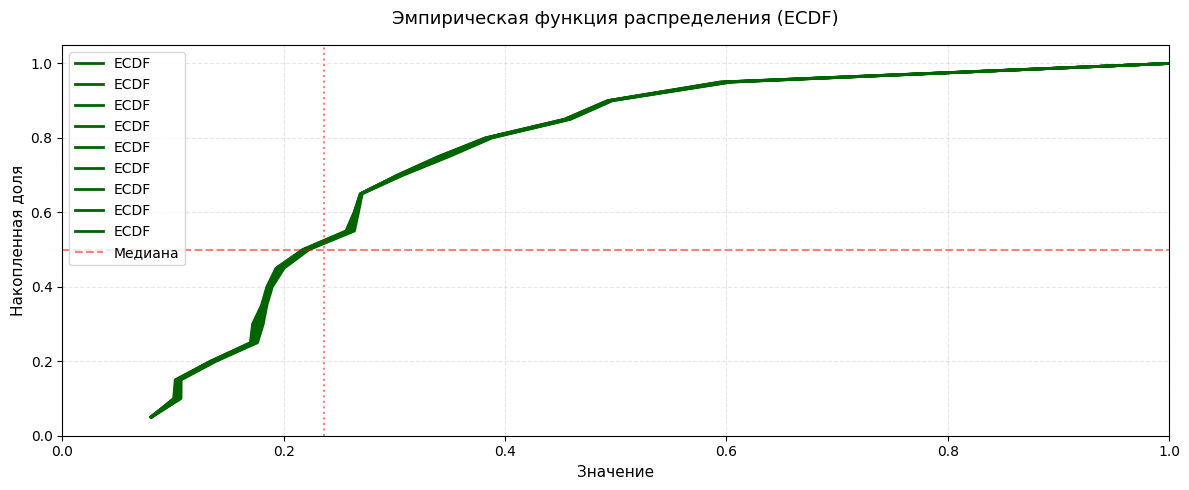

In [113]:
plot_distribution_advanced(entropys, plot_type='ecdf')

In [116]:
import json

with open('ilya_vocab.json', 'r') as file:
    reverse_vocab = json.load(file)

len(reverse_vocab)

115064

In [117]:
vocab = {value: key for key, value in reverse_vocab.items()}

In [118]:
vocab['the']

'98201'

In [105]:
[p for p in ilya_phi[:, int(vocab['the'])]]

[np.float32(0.03263495),
 np.float32(1.6197154e-06),
 np.float32(2.169546e-23),
 np.float32(0.012601097),
 np.float32(0.019396048),
 np.float32(0.00078423554),
 np.float32(1.7684794e-14),
 np.float32(0.003958805),
 np.float32(0.000105620806),
 np.float32(0.019444648),
 np.float32(1.0724022e-09),
 np.float32(0.7035714),
 np.float32(0.0008065288),
 np.float32(0.0419324),
 np.float32(0.053624358),
 np.float32(1.1491047e-09),
 np.float32(2.1584758e-05),
 np.float32(0.057976536),
 np.float32(1.9953916e-07),
 np.float32(0.053139936)]

<BarContainer object of 20 artists>

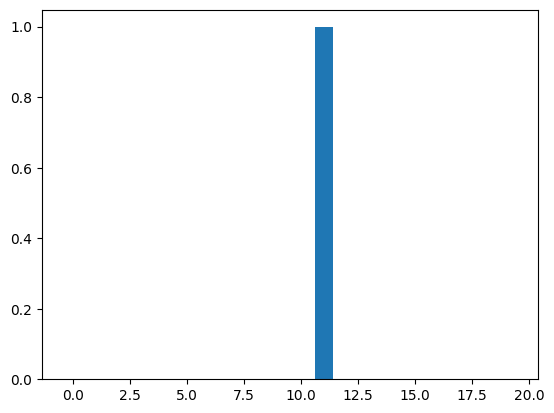

In [114]:
plt.bar(range(20), ilya_phi[:, int(vocab['the'])])

In [92]:
ilya_phi[ilya_phi > 0.99]

array([0.99999994, 0.9996753 , 0.9999999 , ..., 0.99999535, 1.        ,
       0.9966504 ], shape=(95764,), dtype=float32)

In [93]:
mask = (ilya_phi > 0.99).any(axis=0)  # True для столбцов, содержащих хотя бы одну 1
result = ilya_phi[:, mask]          # выборка столбцов

In [94]:
result.shape

(20, 95764)

In [95]:
cols_idx = np.where(mask)[0]

In [96]:
cols_idx

array([     0,      2,      3, ..., 115061, 115062, 115063],
      shape=(95764,))

In [ ]:
[reverse_vocab[str(i)] for i in cols_idx]

In [4]:
import json

with open('phi_hist_vocab.json', 'r') as file:
    vocab = json.load(file)
len(vocab)
reverse_vocab = {value: key for key, value in vocab.items()}

In [2]:
phi_hist = np.load('phi_hist.npy').T
phi_hist.shape

(100, 2052, 50)

Text(0.5, 1.0, 'hundred')

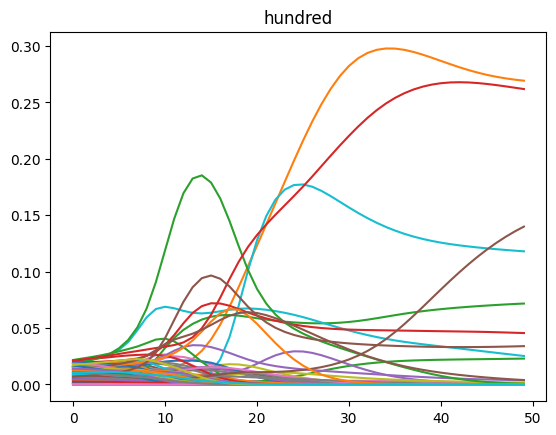

In [9]:
token = 'hundred'
token_hist = [p for p in phi_hist[:, int(vocab[token]), :]]
for i in range(len(token_hist)):
    plt.plot(token_hist[i])
plt.title(token)

Text(0.5, 1.0, 'super')

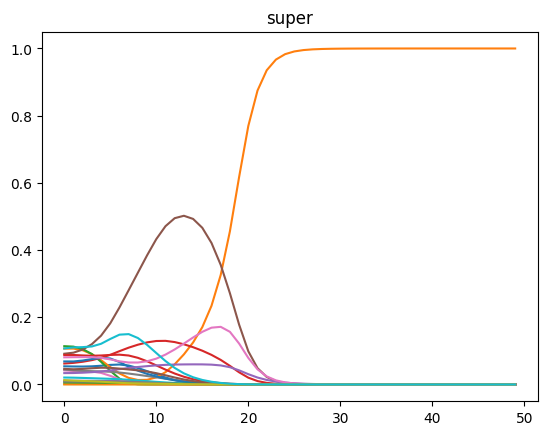

In [170]:
token = 'super'
token_hist = [p for p in phi_hist[:, int(vocab[token]), :]]
for i in range(len(token_hist)):
    plt.plot(token_hist[i])
plt.title(token)

[5.8638316e-33 8.1625375e-20 0.0000000e+00 4.7152620e-28 1.5622051e-29
 4.0739731e-24 0.0000000e+00 7.2167818e-20 3.4064221e-06 4.0946185e-25
 8.7493312e-01 6.1619000e-19 2.0787754e-13 6.9830892e-26 2.3391873e-20
 1.2483741e-01 2.2611898e-04 3.1190416e-25 1.6137779e-08 3.4462321e-22]


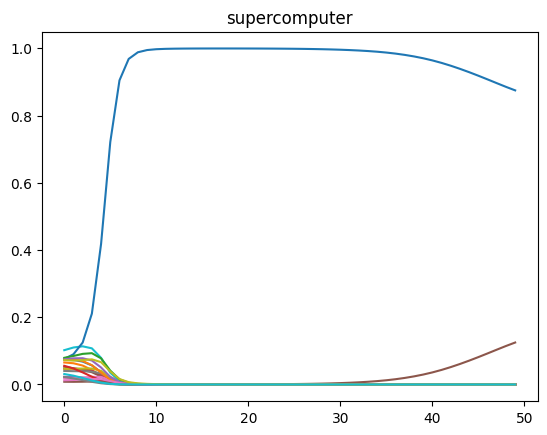

In [203]:
token = 'supercomputer'
token_hist = [p for p in phi_hist[:, int(vocab[token]), :]]
for i in range(len(token_hist)):
    plt.plot(token_hist[i])
plt.title(token)
print(phi_hist[:, int(vocab[token]), -1])

[9.9999988e-01 1.0404790e-34 0.0000000e+00 1.1526705e-31 6.1193036e-21
 3.0218429e-24 0.0000000e+00 5.9565694e-25 0.0000000e+00 1.5287781e-19
 7.0387746e-31 4.3782740e-18 3.7272332e-18 5.2997070e-08 1.5112174e-22
 4.3910945e-36 1.5557137e-29 7.9547648e-09 4.9982635e-39 2.6727180e-19]


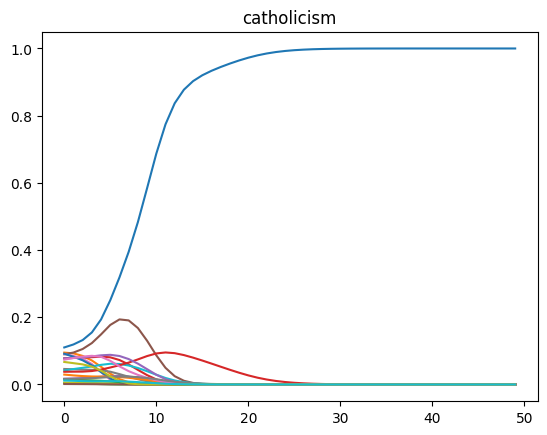

In [202]:
token = 'catholicism'
token_hist = [p for p in phi_hist[:, int(vocab[token]), :]]
for i in range(len(token_hist)):
    plt.plot(token_hist[i])
plt.title(token)
print(phi_hist[:, int(vocab[token]), -1])

Text(0.5, 1.0, 'the')

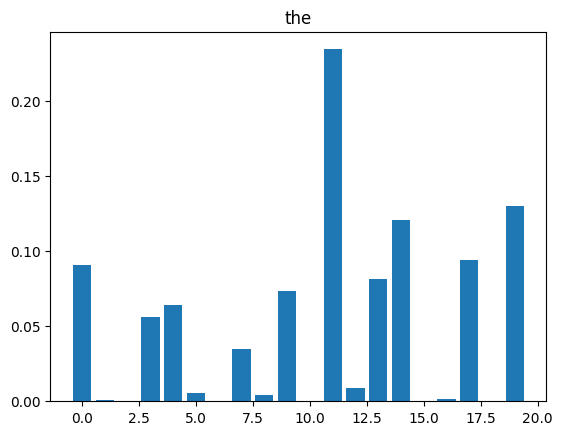

In [197]:
token = 'the'
plt.bar(range(20), phi_hist[:, int(vocab[token]), 10])
plt.title(token)

Text(0.5, 1.0, 'super')

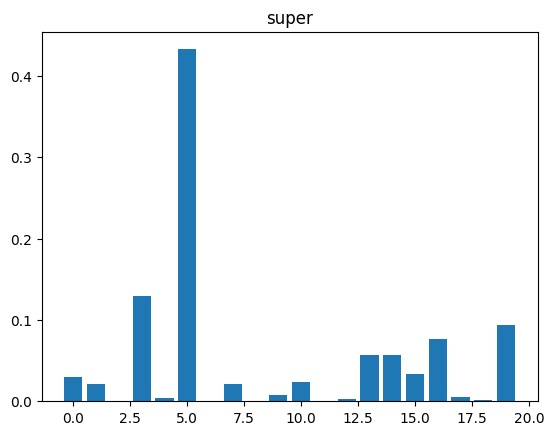

In [199]:
token = 'super'
plt.bar(range(20), phi_hist[:, int(vocab[token]), 10])
plt.title(token)

Text(0.5, 1.0, 'supercomputer')

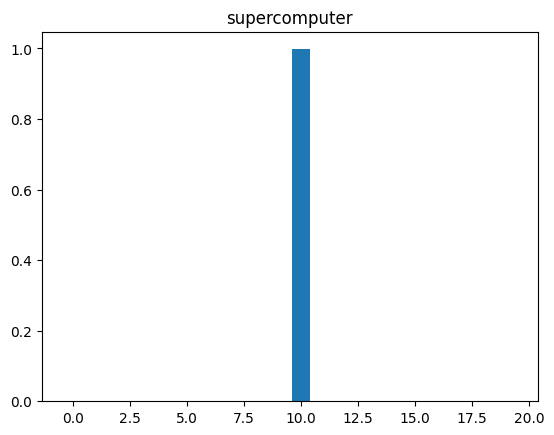

In [198]:
token = 'supercomputer'
plt.bar(range(20), phi_hist[:, int(vocab[token]), 10])
plt.title(token)

In [183]:
np.sum(phi_hist[:, :, -1], axis=1)
plt.bar(range(20), phi_hist[:, int(vocab['supercomputer']), 10])

array([ 6716.2603,  5183.4604,  1550.1204,  3549.8696,  5072.6025,
        2072.4297, 19100.52  ,  5127.8203,  7443.3047,  2674.2751,
       11594.847 ,  3505.0474,  3644.2246,  3395.1553,  4283.7974,
        9514.928 ,  5906.6733,  3856.6052,  8796.604 ,  2075.1763],
      dtype=float32)

In [187]:
mask = (phi_hist[:, :, -1] > 0.99).any(axis=0)  # True для столбцов, содержащих хотя бы одну 1
result = phi_hist[:, mask, -1]         # выборка столбцов
result.shape

(20, 95763)

In [189]:
cols_idx = np.where(mask)[0]
cols_idx

array([     0,      2,      3, ..., 115061, 115062, 115063],
      shape=(95763,))

Text(0.5, 1.0, 'Распределение якорных слов по темам')

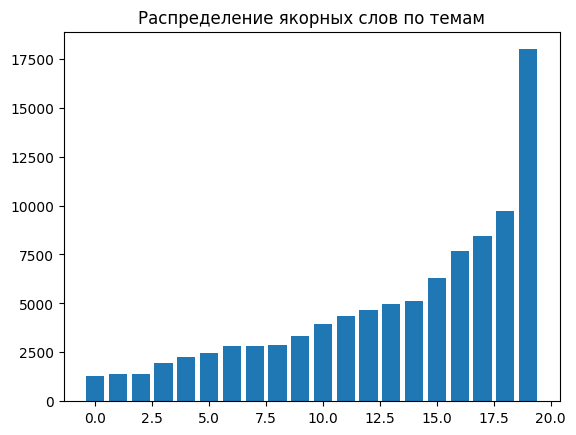

In [193]:
plt.bar(range(20), np.sort(np.sum(result, axis=1)))
plt.title("Распределение якорных слов по темам")

# Сравнение всего корпуса и фильтрованного

In [11]:
import json

with open('all_phi_hist_vocab.json', 'r') as file:
    all_vocab = json.load(file)
    all_reverse_vocab = {value: key for key, value in vocab.items()}

with open('filtered_phi_hist_vocab.json', 'r') as file:
    filtered_vocab = json.load(file)
    filtered_reverse_vocab = {value: key for key, value in vocab.items()}

print(f"{len(all_vocab)=}")
print(f"{len(filtered_vocab)=}")

len(all_vocab)=20249
len(filtered_vocab)=4296


In [12]:
all_phi_hist = np.load('all_phi_hist.npy').T
filtered_phi_hist = np.load('filtered_phi_hist.npy').T
print(f"{all_phi_hist.shape=}")
print(f"{filtered_phi_hist.shape=}")

all_phi_hist.shape=(100, 20249, 50)
filtered_phi_hist.shape=(100, 4296, 50)


[8.1246449e-26 0.0000000e+00 0.0000000e+00 1.1985998e-25 1.7454812e-24
 0.0000000e+00 8.3149843e-02 0.0000000e+00 0.0000000e+00 6.6705330e-12
 0.0000000e+00 0.0000000e+00 0.0000000e+00 1.3177449e-21 6.5421575e-01
 7.2800194e-29 0.0000000e+00 0.0000000e+00 0.0000000e+00 1.3987447e-01
 0.0000000e+00 1.7845777e-11 0.0000000e+00 0.0000000e+00 2.2397723e-11
 5.5197296e-13 0.0000000e+00 0.0000000e+00 0.0000000e+00 1.5229718e-25
 6.9300000e-12 9.9086980e-24 0.0000000e+00 0.0000000e+00 0.0000000e+00
 0.0000000e+00 7.3211756e-11 0.0000000e+00 2.0610122e-15 1.1020765e-29
 2.7896652e-26 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00
 6.5186307e-02 0.0000000e+00 3.0564993e-32 0.0000000e+00 1.1213127e-30
 0.0000000e+00 1.5632454e-09 3.1639177e-32 2.3239748e-10 0.0000000e+00
 1.7392568e-06 8.3051757e-26 5.4974478e-14 4.5691025e-17 3.3816424e-17
 2.7920900e-02 0.0000000e+00 1.2683471e-32 1.1221242e-06 4.0619182e-33
 0.0000000e+00 6.2552407e-34 0.0000000e+00 0.0000000e+00 0.0000000e+00
 0.000

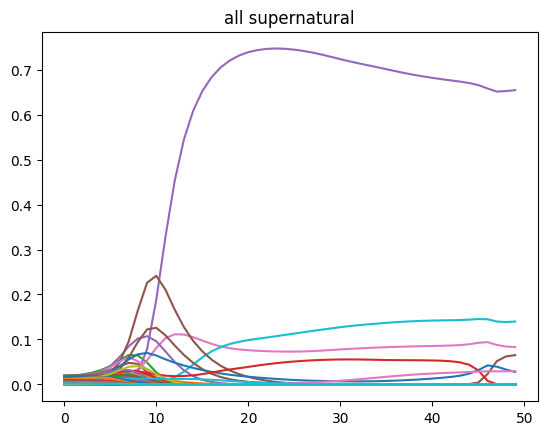

In [24]:
token = 'supernatural'
token_hist = [p for p in all_phi_hist[:, int(all_vocab[token]), :]]
for i in range(len(token_hist)):
    plt.plot(token_hist[i])
plt.title('all ' + token)
print(all_phi_hist[:, int(all_vocab[token]), -1])

[6.1653037e-11 0.0000000e+00 0.0000000e+00 2.4067838e-31 0.0000000e+00
 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 9.4687324e-03
 0.0000000e+00 1.5631263e-33 0.0000000e+00 6.5272047e-20 2.1264044e-33
 0.0000000e+00 3.7296552e-25 8.7060681e-28 7.0930683e-27 0.0000000e+00
 1.1421382e-31 2.9089806e-31 0.0000000e+00 2.4814591e-02 0.0000000e+00
 0.0000000e+00 2.9714794e-23 2.4491572e-17 0.0000000e+00 3.7183384e-30
 6.1710119e-01 0.0000000e+00 1.8435035e-32 0.0000000e+00 0.0000000e+00
 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 1.4268175e-01
 1.1073194e-27 0.0000000e+00 4.0965007e-22 1.2344482e-22 0.0000000e+00
 2.4213962e-02 6.4173896e-26 6.4798406e-33 0.0000000e+00 6.3693108e-08
 4.5911041e-03 1.3538222e-28 0.0000000e+00 1.9233054e-31 8.3985602e-21
 3.1782425e-33 2.7272416e-20 1.6267493e-18 0.0000000e+00 0.0000000e+00
 2.2778090e-25 1.3899294e-19 0.0000000e+00 0.0000000e+00 3.4276479e-14
 0.0000000e+00 0.0000000e+00 7.3012436e-27 1.5927528e-24 3.1432780e-28
 0.000

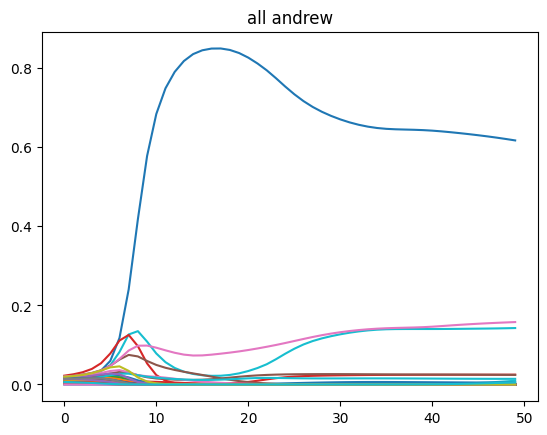

In [20]:
token = 'andrew'
token_hist = [p for p in all_phi_hist[:, int(all_vocab[token]), :]]
for i in range(len(token_hist)):
    plt.plot(token_hist[i])
plt.title('all ' + token)
print(all_phi_hist[:, int(all_vocab[token]), -1])

[0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00
 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00
 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00
 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00
 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00
 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00
 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00
 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00
 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00
 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00
 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 8.731627e-33
 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00
 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00
 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00
 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00
 0.000000e

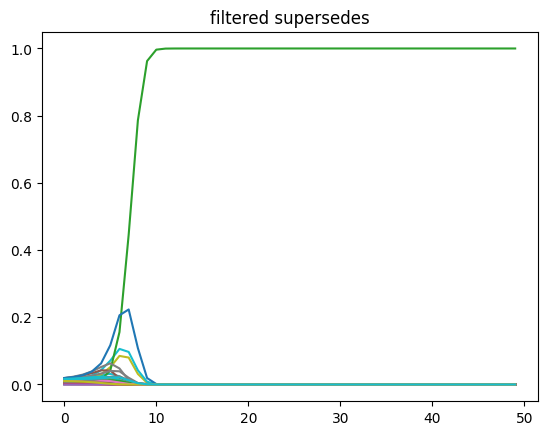

In [25]:
token = 'supersedes'
token_hist = [p for p in all_phi_hist[:, int(filtered_vocab[token]), :]]
for i in range(len(token_hist)):
    plt.plot(token_hist[i])
plt.title('filtered ' + token)
print(filtered_phi_hist[:, int(filtered_vocab[token]), -1])

In [22]:
[k for k in filtered_vocab if k.startswith('super')]

['super', 'superior', 'supernatural', 'supersedes']

In [28]:
ilya_phi = np.load('all_phi_hist.npy').T
ilya_phi.shape

(100, 115064, 50)

In [39]:
perplexity_history = [5911.5078125, 5691.67578125, 5918.5810546875, 5885.8779296875, 6032.4033203125, 6294.771484375, 6183.76708984375, 6881.47216796875, 6320.1015625, 7615.14892578125, 6408.52685546875, 8475.30859375, 6426.59375, 9452.0771484375, 6336.60791015625, 10541.296875, 6059.3642578125, 11734.08984375, 5480.9228515625, 13000.859375, 4599.27001953125, 14279.2216796875, 3640.359375, 15529.6591796875, 2844.32373046875, 16785.43359375, 2277.087158203125, 18132.443359375, 1899.64306640625, 19661.193359375, 1651.876220703125, 21436.427734375, 1486.949462890625, 23495.9140625, 1374.376220703125, 25863.876953125, 1295.3575439453125, 28563.578125, 1238.2711181640625, 31620.044921875, 1195.8822021484375, 35061.26953125, 1163.5126953125, 38918.84765625, 1138.080078125, 43227.59765625, 1117.7366943359375, 48025.78515625, 1101.3946533203125, 53352.59375, 1088.1904296875, 59242.765625, 1077.3316650390625, 65714.8046875, 1068.191650390625, 72755.1328125, 1060.3824462890625, 80295.46875, 1053.6693115234375, 88186.484375, 1047.876220703125, 96181.3203125, 1042.8302001953125, 103947.625, 1038.3753662109375, 111119.609375, 1034.4173583984375, 117380.359375, 1030.8917236328125, 122533.0390625, 1027.7230224609375, 126532.421875, 1024.8446044921875, 129464.625, 1022.1949462890625, 131502.015625, 1019.7485961914062, 132847.234375, 1017.501220703125, 133692.03125, 1015.4635620117188, 134195.203125, 1013.6256713867188, 134476.140625, 1011.9484252929688, 134619.09375, 1010.3896484375, 134679.578125, 1008.9058227539062, 134691.125, 1007.4597778320312, 134674.3125, 1006.0603637695312, 134640.78125, 1004.7559204101562, 134598.671875, 1003.559326171875, 134551.703125, 1002.4803466796875, 134502.828125]

In [40]:
len(perplexity_history)

100

In [41]:
train_perplexity_history = perplexity_history[::2]
test_perplexity_history = perplexity_history[1::2]

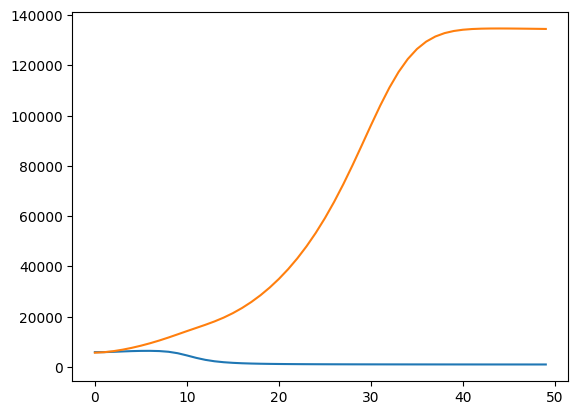

In [42]:
plt.plot(train_perplexity_history)
plt.plot(test_perplexity_history)